## Importowanie bibliotek

In [2]:
# Importy potrzebne do analizy szeregów czasowych i trenowania modeli
import os
import sys
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)
from sklearn.ensemble import RandomForestClassifier

# Gradient boosting
import xgboost as xgb
import lightgbm as lgb

# Deep learning (optional)
import tensorflow as tf
import torch

# Utilities
from tqdm import tqdm
import joblib
import pickle

# Set visualization defaults
sns.set(style="whitegrid")

## Ładowanie danych

In [3]:
base_path = '../dataset'
train_path = os.path.join(base_path, 'data/data/train')
test_path = os.path.join(base_path, 'data/data/test')

In [5]:
anomaly_df = pd.read_csv(os.path.join(base_path, 'labeled_anomalies.csv'))
anomaly_df.head()

,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307


In [6]:
print(f"Total labeled channels: {len(anomaly_df)}")
anomaly_df.info()

Total labeled channels: 82
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   chan_id            82 non-null     object
 1   spacecraft         82 non-null     object
 2   anomaly_sequences  82 non-null     object
 3   class              82 non-null     object
 4   num_values         82 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 3.3+ KB


In [7]:
print("Anomaly distribution by spacecraft:")
anomaly_df.groupby('spacecraft').agg({'chan_id': 'count', 'num_values': 'sum'}).rename(columns={'chan_id': 'channels', 'num_values': 'total_values'})

Anomaly distribution by spacecraft:


,channels,total_values
spacecraft,,
MSL,27,73729
SMAP,55,444035


In [8]:
train_files = os.listdir(train_path)
test_files = os.listdir(test_path)

print(f"Training files: {len(train_files)}")
print(f"Testing files: {len(test_files)}")

Training files: 82
Testing files: 82


In [11]:
sample_channel = train_files[0]
sample_data = np.load(f'{train_path}/{sample_channel}')

print(f"Sample channel: {sample_channel}")
print(f"Shape: {sample_data.shape}")
print(f"Data type: {sample_data.dtype}")

Sample channel: A-1.npy
Shape: (2880, 25)
Data type: float64


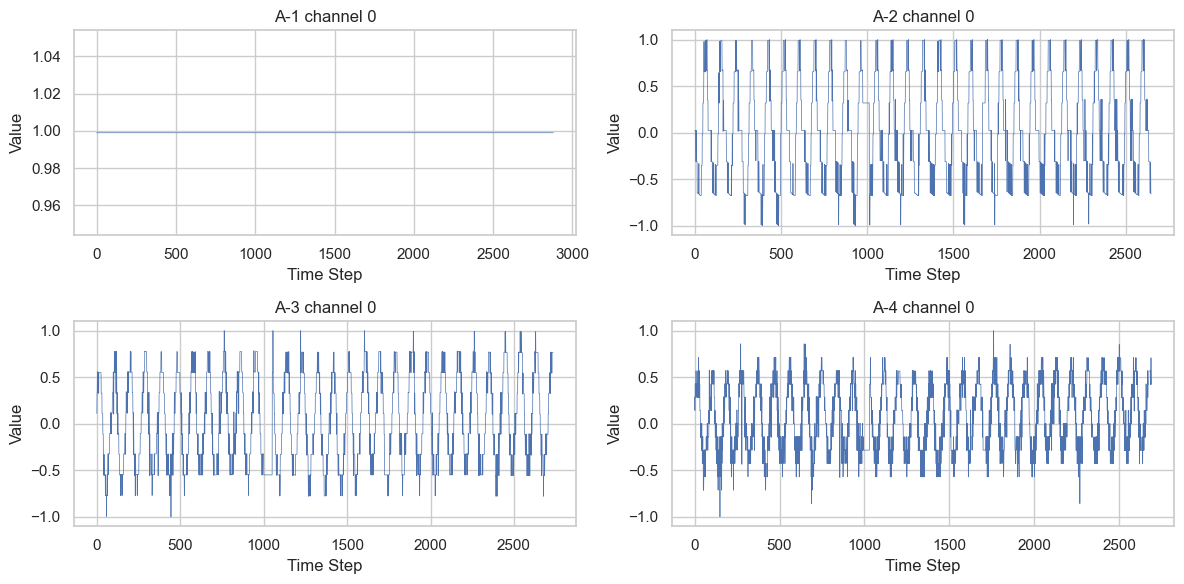

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for idx, ax in enumerate(axes.flat):
    if idx < len(train_files):
        channel_name = train_files[idx]
        data = np.load(f'{train_path}/{channel_name}')
        ax.plot(data[:, 0], linewidth=0.5)
        ax.set_title(channel_name.replace('.npy', ' channel 0'))
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

## Wizualizacja obszarów z anomaliami

In [14]:
anomaly_channel = anomaly_df.iloc[0]
channel_id = anomaly_channel['chan_id']
anomaly_ranges = anomaly_channel['anomaly_sequences']

print(f"Channel: {channel_id}")
print(f"Spacecraft: {anomaly_channel['spacecraft']}")
print(f"Anomaly ranges: {anomaly_ranges}")

Channel: P-1
Spacecraft: SMAP
Anomaly ranges: [[2149, 2349], [4536, 4844], [3539, 3779]]


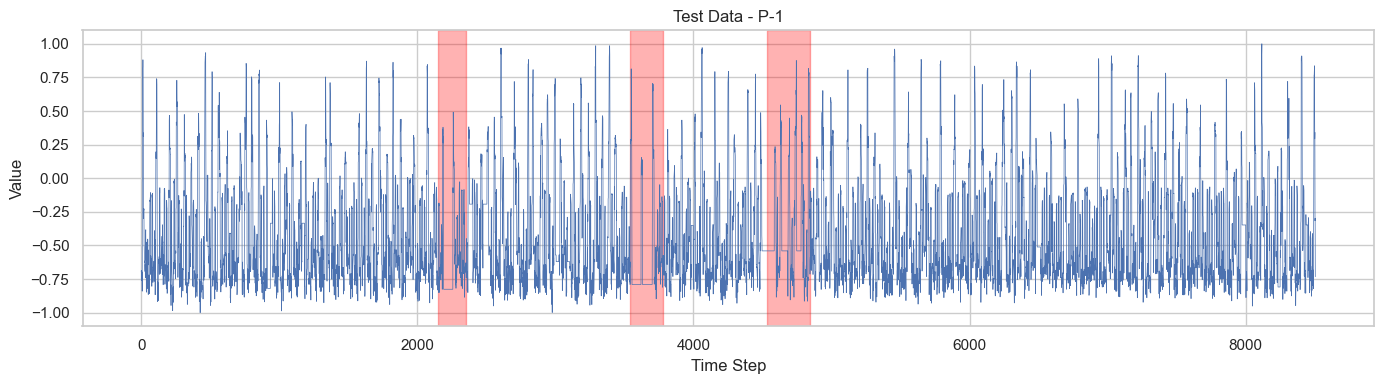

In [17]:
import ast

test_data = np.load(f'{test_path}/{channel_id}.npy')

# Convert anomaly_ranges from string to list of lists
anomaly_ranges = ast.literal_eval(anomaly_ranges)

plt.figure(figsize=(14, 4))
plt.plot(test_data[:, 0], linewidth=0.5, label='Telemetry Signal')

for start, end in anomaly_ranges:
    plt.axvspan(start, end, alpha=0.3, color='red', label='Anomaly')

plt.title(f'Test Data - {channel_id}')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

## Ekstrakcja cech z okna czasowego

In [ ]:
import ast
import numpy as np
import pandas as pd

def ranges_overlap(a_s, a_e, b_s, b_e):
    return not (a_e < b_s or a_s > b_e)

# Funkcja do etykietowania okien czasowych na podstawie zakresów anomalii
# Zwraca 1, jeśli w przyszłości (po t_end) wystąpi anomalia, 0 w przeciwnym razie
def label_for_end(t_end, H, anomaly_ranges):
    future_s = t_end + 1
    future_e = t_end + H
    for a_s, a_e in anomaly_ranges:
        if ranges_overlap(a_s, a_e, future_s, future_e):
            return 1
    return 0

# Etykietowanie okien czasowych na podstawie zakresów anomalii
# Zwraca X (okna), y (etykiety) i starts (indeksy początków okien)
def windows_labels_from_array(data, W, H, step=1, anomaly_ranges=None):
    # data: np.ndarray shape (T, C) or (T,)
    if data.ndim == 1:
        data = data.reshape(-1, 1)
    T = data.shape[0]
    anomaly_ranges = anomaly_ranges or []
    X_windows = []
    y = []
    starts = []
    # t_end is index of 'now' (end of window); future is after t_end
    for t_end in range(W - 1, T - H, step):
        start = t_end - W + 1
        window = data[start:t_end + 1].copy()   # shape (W, C)
        X_windows.append(window)
        y.append(label_for_end(t_end, H, anomaly_ranges))
        starts.append(start)
    X = np.stack(X_windows, axis=0) if len(X_windows) > 0 else np.empty((0, W, data.shape[1]))
    return X, np.array(y), starts

# Funkcja do ekstrakcji cech z okien czasowych
# Zwraca DataFrame z cechami statystycznymi dla każdego kanału w oknie
def windows_to_feature_df(X_windows):
    # X_windows: (N, W, C) -> returns DataFrame with flattened per-channel stats
    feats = []
    if X_windows.size == 0:
        return pd.DataFrame()
    N, W, C = X_windows.shape
    for i in range(N):
        w = X_windows[i]
        row = {}
        for ch in range(C):
            col = w[:, ch]
            row[f'ch{ch}_mean'] = np.mean(col)
            row[f'ch{ch}_std']  = np.std(col)
            row[f'ch{ch}_min']  = np.min(col)
            row[f'ch{ch}_max']  = np.max(col)
            row[f'ch{ch}_range'] = np.max(col) - np.min(col)
            row[f'ch{ch}_slope'] = np.polyfit(np.arange(W), col, 1)[0]
        feats.append(row)
    return pd.DataFrame(feats)